# Algoritmes voor ontwerp van een nok


In [173]:
import numpy as np
import matplotlib.pyplot as plt



<h3>Specificaties</h3>

<a id="specs">Bewegingsspecificatie:</a>

- van 20° tot 90°: heffing van +25 mm.
- van 90° tot 155°: heffing van -15 mm.
- van 155° tot 165°: stilstand op 10 mm.
- van 165° tot 200°: heffing van -10 mm.

De equivalente massa en demping van de volger zijn 30 kg en 0.07.
De volgende statische krachten moeten gerealiseerd worden:

- van 20° tot 90°: een lineair toenemende drukkracht van 0 N tot 550 N.
- van 90° tot 155°: een constante trekkracht van 250 N.
- van 155° tot 165°: geen krachtoverdracht
- van 165° tot 180°: een constante trekkracht van 295 N.

De beweging moet uitgevoerd zijn in 1 seconde.


In [174]:
# specifications:

startangle1 = 20 # degrees
endangle1   = 90 # degrees
theta_seg1  = endangle1 - startangle1 # rotation length for first motion segment
startlift1  =  0
endlift1    = 25
motionlaw1  =  5

startangle2 =  90 # degrees
endangle2   = 155 # degrees
theta_seg2  = endangle2 - startangle2 # rotation length for second segment
startlift2  =  25
endlift2    =  10
motionlaw2  =   5

startangle3 = 155 # degrees
endangle3   = 165 # degrees
theta_seg3  = endangle3 - startangle3 # rotation length for third segment
startlift3  =  10
endlift3    =  10
motionlaw3  =   1

startangle4 = 165 # degrees
endangle4   = 200 # degrees
theta_seg4  = endangle4 - startangle4 # rotation length for fourth segment
startlift4  =  10
endlift4    =   0
motionlaw4  =   5

startangleload1 =   20
endangleload1   =   90
startload1      =    0
endload1        =  550

startangleload2 =   90
endangleload2   =  155
startload2      = -250
endload2        = -250

startangleload3 =  155
endangleload3   =  165
startload3      = 0
endload3        = 0

startangleload4 =  165
endangleload4   =  200
startload4      = -295
endload4        = -295


In [175]:
# Simulation variables of cam:

dtheta = 0.01 # resolution of simulation, in degrees

theta_deg      = np.arange(0,360,dtheta) # array of cam angles in degrees
theta          = theta_deg*np.pi/180     # array of cam angles in radians
lift           = np.zeros(len(theta))    # lift follower in mm
vel            = np.zeros(len(theta))    # velocity follower in mm/rad
vel_deg        = np.zeros(len(theta))    # velocity follower in mm/degree
acc            = np.zeros(len(theta))    # acceleration follower in mm/rad^2
acc_deg        = np.zeros(len(theta))    # acceleration follower in mm/degree^2
ext_load       = np.zeros(len(theta))    # external load in N
pressure_angle = np.zeros(len(theta))    # pressure angle in radians

# Orientation switch:
#  1 = current orientation (cam below follower)
# -1 = flipped orientation (cam above follower, follower below)
orientation = -1

# Cam design parameters, as output of the analysis
base_radius     = [] # base circle radius in mm
follower_radius = [] # follower radius in mm
exc             = [] # excentricity in mm
mass            = [] # equivalent mass in kg
spring_constant = [] # spring constant in N/mm
spring_preload  = [] # spring preload in N
rpm             = [] # rotations per minute of the cam
omega           = [] # angular velocity of the cam in rad/s

# search space of possible R0 values [mm]:
R0_min          =   0
R0_max          = 100 
R0_delta        =   0.1 
R0_vec          = np.arange(R0_min, R0_max, R0_delta) 
# maximum pressure angle corresponding to the evaluated R0s:
alpha_max       = np.zeros_like(R0_vec)

beta_vec        = np.arange(1, 360, 0.1)  # sampling resolution for rotation
rho_min         = np.zeros_like(beta_vec) # minimal follower radius at each beta

# input parameters of several analysis functions:
beta            = [] # cam angle interval of the segment
startangle      = [] # start angle of the segment in degrees
endangle        = [] # end angle of the segment in degrees
startlift       = [] # start lift of the segment in mm
endlift         = [] # end lift of the segment in mm
startangleload  = [] # start angle of the load in degrees
endangleload    = [] # end angle of the load in degrees
startload       = [] # start load in N
endload         = [] # end load in N
motionlaw       = [] # choice of motion law:
    # 1: dwell,
	  # 2: minimal rms acceleration,
	  # 3: harmonic,
	  # 4: cycloid,
	  # 5: 5th degree poly,
	  # 6: 7th degree poly

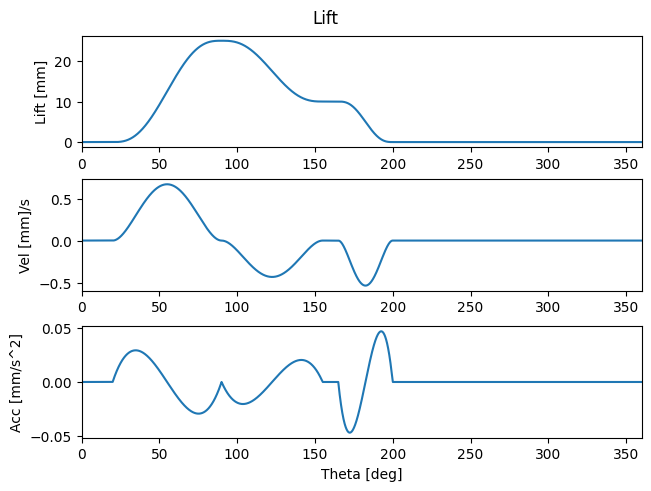

In [176]:
# compute motion functions:

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])


# Add all four segments to the motion law:
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle1,endangle1,startlift1,endlift1,motionlaw1,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle2,endangle2,startlift2,endlift2,motionlaw2,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle3,endangle3,startlift3,endlift3,motionlaw3,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle4,endangle4,startlift4,endlift4,motionlaw4,dtheta)


# Plot the motion law
plotMotionLaw(theta_deg,lift,vel_deg,acc_deg)

plt.show()

In [177]:
# utility functions for external load

def addLoadSegment(startangleload,endangleload,startload,endload,dtheta):
    assert startangleload - endangleload < 0, 'End angle should be bigger than start angle'
    start_index = int(startangleload/dtheta)
    end_index = int(endangleload/dtheta)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (endload - startload)/(endangleload - startangleload)*(theta_segment - startangleload) + startload

    return ext_load

def plotExternalLoad(theta_deg,ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [deg]')
    plt.ylabel('External load [N]')
    plt.xlim([0,360])
    plt.title('External load')


In [178]:
# utility functions for cam profile design (with eccentricity = 0!)

# relate sampled R0 values to pressure angle \alpha:
def Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw):
    global R0_vec, alpha_max
    L0 = startlift
    L1 = endlift
    beta = beta * np.pi / 180
		# 100 samples in dimensionless "arc length" of motion law:
    x = np.arange(0, 1, 0.01)

    for i in range(len(R0_vec)):
        R0 = R0_vec[i]

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        alpha = np.arctan2(vel_ang, R0 + lift)
        alpha_max[i] = np.max(np.abs(alpha)) * 180 / np.pi


# relate given R0 value to samples of curvature radii of motion law:
def Kloomok_Muffley_follower_radius(R0,span,startlift,endlift,motionlaw):
    global beta_vec, rho_min
    L0 = startlift
    L1 = endlift

    for i in range(len(beta_vec)):
        beta = beta_vec[i] * np.pi / 180
        theta = np.linspace(0, beta_vec[i], 100) * np.pi / 180
        x = theta / beta

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        rho = ((R0 + lift)**2 + vel_ang**2)**(3/2) / ((R0 + lift)**2 + 2 * vel_ang**2 - (R0 + lift) * acc_ang)
        rho_min[i] = np.min(np.abs(rho))

    plt.figure()
    plt.plot(beta_vec, rho_min)
    plt.axvline(x=span, color='b')
    plt.text(span, 0.35*R0, 'span of this segment: (%s)'%(span), color='b', ha='right', va='center', rotation='vertical')
    plt.grid()
    plt.xlabel(r'rotation (degrees)')
    plt.ylabel(r'$\rho$ (mm)')
    plt.xlim([0, 360])
    plt.show()


In [179]:
# utility functions for pressure angle

def calculatePressureAngle(vel,exc,base_radius,follower_radius,lift,orientation=1):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    distance = d + lift
    pressure_angle = orientation * np.arctan((vel - exc) / distance)
    return pressure_angle

def plotPressureAngle(theta_deg,pressure_angle):
    plt.figure()
    plt.plot(theta_deg, pressure_angle*180/np.pi)
    plt.xlabel('rotation [deg]')
    plt.ylabel('Pressure angle [deg]')
    plt.xlim([0,360])
    plt.grid()
    plt.title('Pressure angle')


In [180]:
# utility functions for curvature radius

def calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc,orientation=1):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2) # Norton, Kinematics and Dynamics of Machinery eq. 8.31c
    distance = d + lift
    lambda_ = -theta - np.arctan2(exc, distance) + np.pi/2 # adapted for a vertical translating follower
    dlambda = -1 + exc/(distance**2 + exc**2) * vel
    ddlambda = exc/(distance**2 + exc**2)*acc - 2*exc*distance*vel**2/(distance**2 + exc**2)**2

    g = np.sqrt(distance**2 + exc**2)
    dg = vel*distance/np.sqrt(distance**2 + exc**2)
    ddg = (vel**2 + acc*distance)/np.sqrt(distance**2 + exc**2) - (vel**2*distance**2)/(distance**2 + exc**2)**(3/2)

    h = np.sin(lambda_)
    dh = np.cos(lambda_)*dlambda
    ddh = -np.sin(lambda_)*dlambda**2 + np.cos(lambda_)*ddlambda
    f = np.cos(lambda_)
    df = -np.sin(lambda_)*dlambda
    ddf = -np.cos(lambda_)*dlambda**2 - np.sin(lambda_)*ddlambda

    dx = df*g + f*dg
    ddx = ddf*g + 2*df*dg + f*ddg
    dy = orientation * (dh*g + h*dg)
    ddy = orientation * (ddh*g + 2*dh*dg + h*ddg)

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx)
    roc_cam = np.sign(roc_pitch) * (np.abs(roc_pitch) - follower_radius)

    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg,roc_pitch,roc_cam):
    inds = np.where(np.abs(np.diff(roc_pitch)/dtheta)<1e3)[0]
    maxi = max(10, max(roc_pitch[inds+1]))
    mini = min(-10, min(roc_pitch[inds+1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch)
    plt.plot(theta_deg, roc_cam)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Radius of curvature [mm]')
    plt.xlim([0,360])
    plt.ylim([mini,maxi])
    plt.grid()
    plt.title('Radius of curvature')

def plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta,orientation=1):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    distance = d + lift
    lambda_ = -theta - np.arctan2(exc, distance) + np.pi/2
    xpitch = np.cos(lambda_)*np.sqrt(distance**2 + exc**2)
    ypitch = orientation * np.sin(lambda_)*np.sqrt(distance**2 + exc**2)

    pressure_angle_geom = orientation * pressure_angle
    xcam = xpitch + follower_radius*np.cos(-theta + pressure_angle_geom + 3*np.pi/2)
    ycam = ypitch + orientation * follower_radius*np.sin(-theta + pressure_angle_geom + 3*np.pi/2)

    pitch_curve = np.array([xpitch,ypitch])
    cam_curve = np.array([xcam,ycam])

    x_rolfol_center = exc
    y_rolfol_center = orientation * (d + lift[0])
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center
    y_rolfol = orientation * follower_radius * np.sin(theta) + y_rolfol_center

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius

    width_block_on_follower = base_radius / 2
    height_block_on_follower = base_radius / 2

    guide_inner = d + max(lift) + min_distance_center_roller_to_bore
    guide_outer = guide_inner + height_bore
    y_bore = orientation * np.array([guide_inner, guide_inner, guide_outer, guide_outer])
    length_follower = np.abs(y_bore[-1] - ypitch[0]) - follower_radius + 0.2

    x_boreleft = np.array([exc - 5, exc - 1, exc - 1, exc - 5])
    x_boreright = np.array([exc + 5, exc + 1, exc + 1, exc + 5])
    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center + orientation * follower_radius, y_rolfol_center + orientation * (follower_radius + length_follower)])

    x_block_on_follower = np.array([-width_block_on_follower, width_block_on_follower, width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, height_block_on_follower, height_block_on_follower]) * orientation + y_follower[1]

    ref_line = np.array([[0, 0], [0, orientation * base_radius]])

    x_pressangle = np.array([x_rolfol_center + follower_radius * np.sin(pressure_angle[0]), x_rolfol_center - follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = y_rolfol_center + orientation * np.array([-follower_radius * np.cos(pressure_angle[0]), follower_radius * np.cos(pressure_angle[0])])

    plt.figure()
    plt.fill(cam_curve[0, ::int(1 / dtheta)], cam_curve[1, ::int(1 / dtheta)], 'b')
    plt.fill(x_rolfol[::int(1 / dtheta)], y_rolfol[::int(1 / dtheta)], 'g')
    plt.plot(pitch_curve[0, ::int(1 / dtheta)], pitch_curve[1, ::int(1 / dtheta)], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_pressangle, y_pressangle, 'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft, y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower, y_follower, 'r')
    plt.fill(x_block_on_follower, y_block_on_follower, 'g')

    margin = 0.1 * (base_radius + follower_radius + max(lift))
    xlimits = [min(pitch_curve[0, :]) - margin, max(pitch_curve[0, :]) + margin]
    ylimits = [min(np.r_[pitch_curve[1, :], y_bore]) - margin, max(np.r_[pitch_curve[1, :], y_bore]) + margin]

    plt.xlim(xlimits)
    plt.ylim(ylimits)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [mm]')


### Ontwerp van minimale steekcirkel $R_0$

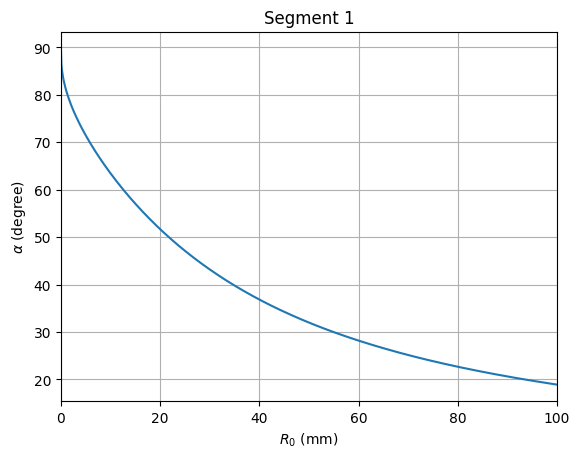

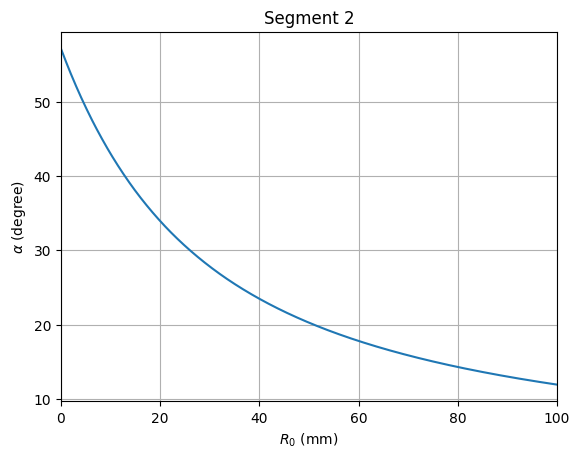

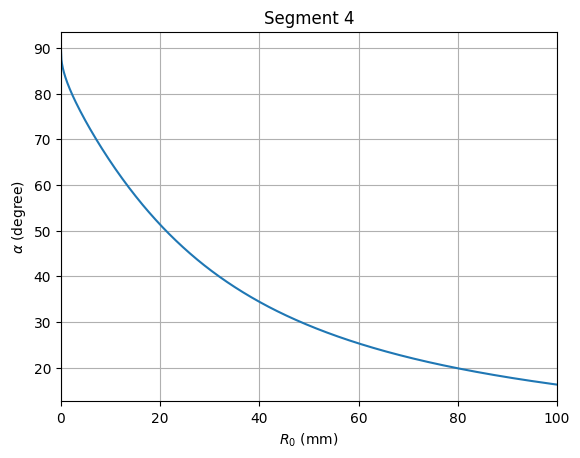

In [181]:
# parameter values for the needed motion segments

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

# The approach was first described by M. Kloomok and R.V. Muffley,
# in Chapter 3 of Mabie, H.H., and Ocvirk, F.W., Mechanisms and Dynamics of Machinery, 1957

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])

# segment 1:
Kloomok_Muffley_R0(theta_seg1,startlift1,endlift1,motionlaw1)

plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 1')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

# segment 2:
Kloomok_Muffley_R0(theta_seg2,startlift2,endlift2,motionlaw2)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 2')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

# segment 3:
Kloomok_Muffley_R0(theta_seg4,startlift4,endlift4,motionlaw4)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 4')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()


Uit bovenstaande plots kan een geschikte waarde voor $R_0$ gekozen worden.
<br>
Hier nemen we $R_0 = 60\text{mm}$, omdat de drukhoek hiermee altijd onder 30 graden blijft.


In [182]:
R0 = 60  # pitch radius in mm 



Pas op: als je de nokspecificaties aan het <a href="#specs">begin</a> van deze notebook wijzigt, dan kies je misschien voor een andere $R_0$.

### Ontwerp van straal $R_r$ van de volger

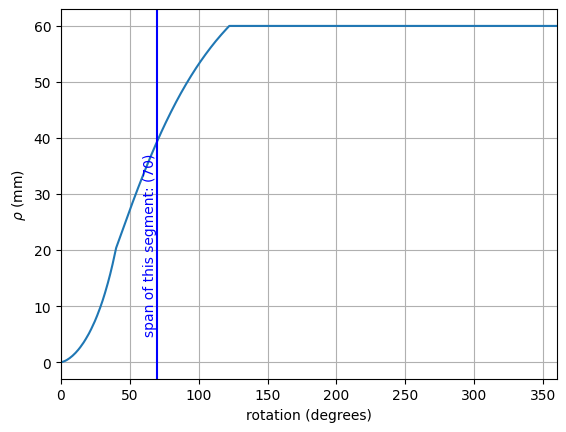

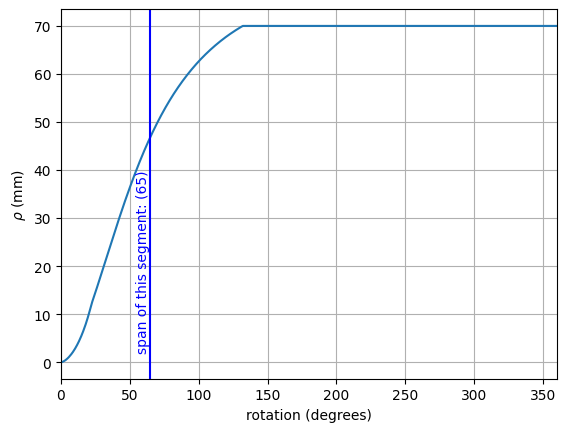

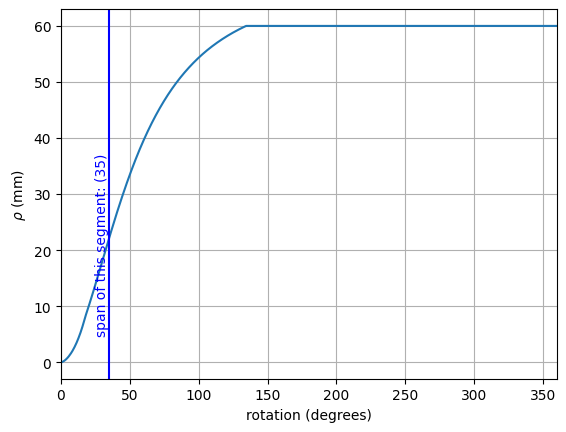

In [183]:
# compute R_r for all segments:

Kloomok_Muffley_follower_radius(R0,theta_seg1,startlift1,endlift1,motionlaw1)
Kloomok_Muffley_follower_radius(R0,theta_seg2,startlift2,endlift2,motionlaw2)
Kloomok_Muffley_follower_radius(R0,theta_seg4,startlift4,endlift4,motionlaw4)

Uit bovenstaande plots kan een geschikte volgrolstraal $R_r$ gekozen worden. De volgrolstraal moet kleiner zijn dan: 40 mm, 50 mm, 25 mm   We nemen $R_r = 15$ mm om goed in de marge te zijn. Dan is de base radius van de nok $R_0 - R_r = 45$ mm.


Min pitch curvature radius during motion = 19.62 mm
Roller radius = 10.00 mm
Curvature margin = 9.62 mm


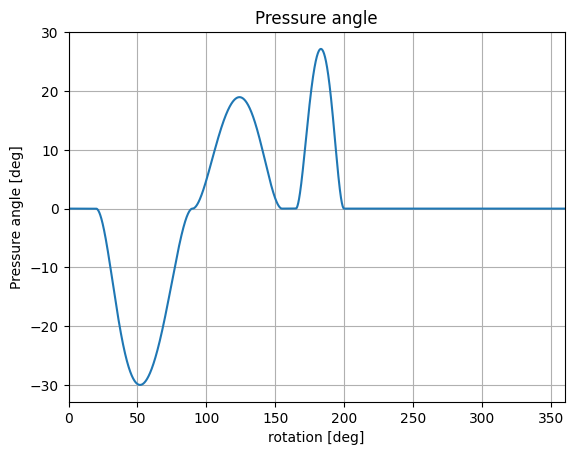

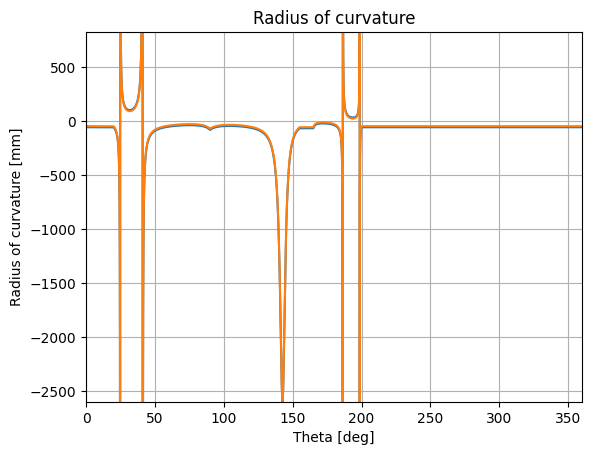

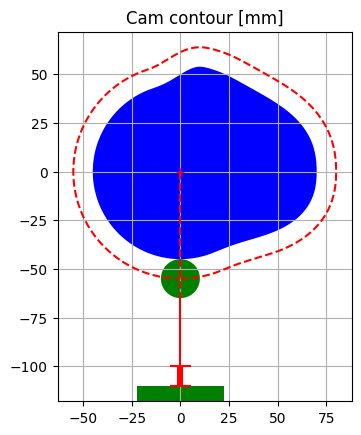

In [184]:
# Kinematics inputs
base_radius     = 45
follower_radius = 10
exc = 0 # excentricity in mm, for now set to 0 for simplicity

# Calculate pressure angle
pressure_angle = calculatePressureAngle(vel,exc,base_radius,follower_radius,lift,orientation)
# Plot pressure angle
plotPressureAngle(theta_deg,pressure_angle)

# Calculate radius of curvature
roc_pitch, roc_cam = calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc,orientation)

moving_mask = ((np.abs(vel) > 1e-9) | (np.abs(acc) > 1e-9)) & np.isfinite(roc_pitch)
min_pitch_radius = np.min(np.abs(roc_pitch[moving_mask]))
roller_margin = min_pitch_radius - follower_radius
print(f'Min pitch curvature radius during motion = {min_pitch_radius:.2f} mm')
print(f'Roller radius = {follower_radius:.2f} mm')
print(f'Curvature margin = {roller_margin:.2f} mm')

# Plot the radius of curvature
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam)

# Plot the cam contour
plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta,orientation)


In [185]:
# Animation of cam contour with translating roller follower
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animateCamFollower(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta,orientation=1,frame_step=300,guide_min_factor=1.0):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    distance = d + lift

    # Same mirrored cam contour calculation as in plotCamContour().
    lambda_ = -theta - np.arctan2(exc, distance) + np.pi/2
    xpitch = np.cos(lambda_)*np.sqrt(distance**2 + exc**2)
    ypitch = orientation * np.sin(lambda_)*np.sqrt(distance**2 + exc**2)
    pressure_angle_geom = orientation * pressure_angle
    xcam = xpitch + follower_radius*np.cos(-theta + pressure_angle_geom + 3*np.pi/2)
    ycam = ypitch + orientation * follower_radius*np.sin(-theta + pressure_angle_geom + 3*np.pi/2)

    frames = np.arange(0, len(theta), frame_step)
    cam_points = np.vstack([xcam, ycam])
    pitch_points = np.vstack([xpitch, ypitch])

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.set_title('Animatie nok met translatievolger')

    max_lift = np.max(lift)
    y0 = orientation * (d + lift[0])
    x_min = -base_radius - follower_radius - 25
    x_max = base_radius + follower_radius + 35

    # Fixed guide/slot for the translating follower. Keep it away from the rotating cam.
    guide_gap = 2.4*follower_radius
    guide_width = 0.18*follower_radius
    guide_left_x = exc - guide_gap/2
    guide_right_x = exc + guide_gap/2
    if orientation == 1:
        guide_y_start = d + guide_min_factor*follower_radius
        guide_y_end = d + max_lift + 4*follower_radius
    else:
        lowest_roller_center = np.min(orientation * (d + lift))
        guide_y_start = lowest_roller_center - 2*follower_radius
        guide_y_end = guide_y_start - 5*follower_radius

    y_min = min(-base_radius - follower_radius - 15, guide_y_start, guide_y_end) - 10
    y_max = max(d + max_lift + 4*follower_radius, -guide_y_start, -guide_y_end)
    if orientation == -1:
        y_max = base_radius + follower_radius + 20
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.plot([guide_left_x, guide_left_x], [guide_y_start, guide_y_end], color='0.45', lw=4, label='geleiding')
    ax.plot([guide_right_x, guide_right_x], [guide_y_start, guide_y_end], color='0.45', lw=4)

    # Moving artists.
    cam_line, = ax.plot([], [], color='tab:blue', lw=2.5, label='nok')
    pitch_line, = ax.plot([], [], '--', color='tab:red', lw=1.2, label='steekkromme')
    ref_line, = ax.plot([], [], color='black', lw=1.5, label='referentielijn')
    roller = plt.Circle((exc, y0), follower_radius, fill=False, color='tab:green', lw=2.5)
    ax.add_patch(roller)
    follower_line, = ax.plot([], [], color='tab:green', lw=3)
    follower_block = plt.Rectangle((exc-guide_gap/2+guide_width, y0+orientation*follower_radius),
                                   guide_gap-2*guide_width, orientation*follower_radius,
                                   fill=False, edgecolor='tab:green', lw=2)
    ax.add_patch(follower_block)
    angle_text = ax.text(0.03, 0.95, '', transform=ax.transAxes)

    ax.plot(0, 0, 'k+', markersize=10)
    ax.legend(loc='lower right')

    def rotate(points, angle):
        c = np.cos(angle)
        s = np.sin(angle)
        rot = np.array([[c, -s], [s, c]])
        return rot @ points

    def update(frame_index):
        i = frames[frame_index]
        angle = orientation * theta[i]

        # Rotate the cam; follower stays vertical in the fixed guide.
        cam_rot = rotate(cam_points, angle)
        pitch_rot = rotate(pitch_points, angle)
        ref_rot = rotate(np.array([[0, 0], [0, orientation * base_radius]]), angle)

        cam_line.set_data(cam_rot[0], cam_rot[1])
        pitch_line.set_data(pitch_rot[0], pitch_rot[1])
        ref_line.set_data(ref_rot[0], ref_rot[1])

        y_center = orientation * (d + lift[i])
        roller.center = (exc, y_center)
        follower_line.set_data([exc, exc], [y_center+orientation*follower_radius, y_center+orientation*3.2*follower_radius])
        follower_block.set_xy((exc-guide_gap/2+guide_width, y_center+orientation*3.2*follower_radius))
        angle_text.set_text(f'theta = {theta[i]*180/np.pi:.1f} deg, lift = {lift[i]:.1f} mm')

        return cam_line, pitch_line, ref_line, roller, follower_line, follower_block, angle_text

    anim = FuncAnimation(fig, update, frames=len(frames), interval=40, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())

animateCamFollower(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta,orientation,guide_min_factor=1.0)


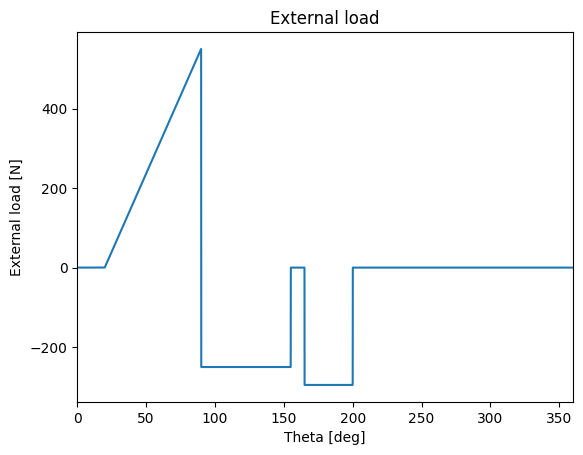

In [186]:
# generate external load

ext_load = addLoadSegment(startangleload1,endangleload1,startload1,endload1,dtheta)
ext_load = addLoadSegment(startangleload2,endangleload2,startload2,endload2,dtheta)
ext_load = addLoadSegment(startangleload3,endangleload3,startload3,endload3,dtheta)
ext_load = addLoadSegment(startangleload4,endangleload4,startload4,endload4,dtheta)

plotExternalLoad(theta_deg,ext_load)



### Ontwerp Veer:

Verticale krachtenevenwicht met zwaartekracht en geleidingswrijving, voor beide opstellingen:

- `orientation = 1`: de nok zit onder de volger en duwt de volger omhoog.
- `orientation = -1`: de nok zit boven de volger en duwt de volger omlaag.
- De veer duwt altijd naar de nok toe: bij nok onderaan naar beneden, bij nok bovenaan naar boven.
- De fysieke snelheid en versnelling van de volger zijn `orientation*vel` en `orientation*acc`.
- De wrijvingskracht in de geleiding werkt tegengesteld aan die fysieke snelheid.

Met positieve kracht naar boven geldt:

`orientation*N*cos(alfa) - mu*abs(N*sin(alfa))*sign(dy/dt) - orientation*F_veer - F_ext - m*g = m*a`

Daaruit worden de nodige veerconstante, veervoorspanning en normaalkracht automatisch met het juiste teken berekend.


In [ ]:
mass = 1.0
rpm = 60
g_const = 9.81       # [m/s^2]
mu = 0.08            # [-] inox plunjer met kunststof/PTFE-achtige glijgeleiding
omega = rpm*2*np.pi/60

follower_velocity = orientation * vel*omega          # dy/dt [mm/s], positief naar boven
follower_acceleration = orientation * acc*omega**2   # d2y/dt2 [mm/s^2], positief naar boven

force_acc = mass*follower_acceleration/1000  # [N], positief naar boven in de bewegingsvergelijking
force_gravity = mass*g_const                 # [N], werkt altijd naar beneden
velocity_sign = np.sign(follower_velocity)

# Door wrijving hangt N impliciet af van zichzelf via R = N*sin(alpha).
# Wrijving werkt tegengesteld aan de fysieke snelheid van de volger.
friction_denominator = orientation*np.cos(pressure_angle) - mu*np.abs(np.sin(pressure_angle))*velocity_sign

plt.figure()
plt.plot(theta_deg, follower_velocity)
plt.xlabel('Theta [deg]')
plt.ylabel('dy/dt [mm/s]')
plt.xlim([0,360])
plt.grid()
plt.title('Follower velocity')

plt.figure()
plt.plot(theta_deg, follower_acceleration)
plt.xlabel('Theta [deg]')
plt.ylabel('d2y/dt2 [mm/s^2]')
plt.xlim([0,360])
plt.grid()
plt.title('Follower acceleration')

plt.figure()
plt.plot(theta_deg, force_acc, label='inertia term')
plt.plot(theta_deg, -force_gravity*np.ones_like(theta_deg), label='gravity')
plt.xlabel('Theta [deg]')
plt.ylabel('Force [N], positive upward')
plt.xlim([0,360])
plt.grid()
plt.legend()
plt.title('Inertiekracht en zwaartekracht')
contact_margin=0

def calculateSpringConstant(rpm,lift,vel,acc,pressure_angle,ext_load,mass,spring_preload,mu=0.15,g_const=9.81,contact_margin=0,orientation=1):
    omega = rpm*2*np.pi/60
    follower_velocity = orientation * vel*omega
    follower_acceleration = orientation * acc*omega**2

    force_acc = mass*follower_acceleration/1000
    force_gravity = mass*g_const
    velocity_sign = np.sign(follower_velocity)
    denominator = orientation*np.cos(pressure_angle) - mu*np.abs(np.sin(pressure_angle))*velocity_sign

    # Uit: N = (force_acc + orientation*F_spring + ext_load + force_gravity) / denominator.
    # Voor orientation = -1 draait de ongelijkheid door de negatieve denominator om; deze vorm vangt dat af.
    required_spring_force = orientation * (contact_margin*denominator - force_acc - ext_load - force_gravity)

    mask = lift > 1e-6
    k_values = (required_spring_force[mask] - spring_preload)/lift[mask]

    spring_constant = np.max(k_values)
    spring_constant = max(0,spring_constant)

    critical_index = np.where(mask)[0][np.argmax(k_values)]

    return spring_constant, critical_index, required_spring_force


In [ ]:
def calculateForce(rpm,lift,vel,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc,mu=0.15,g_const=9.81,orientation=1):
    omega = rpm*2*np.pi/60
    follower_velocity = orientation * vel*omega
    follower_acceleration = orientation * acc*omega**2

    spring_force = lift*spring_constant + spring_preload
    force_acc = mass*follower_acceleration/1000
    force_gravity = mass*g_const
    velocity_sign = np.sign(follower_velocity)

    denominator = orientation*np.cos(pressure_angle) - mu*np.abs(np.sin(pressure_angle))*velocity_sign
    numerator = force_acc + orientation*spring_force + ext_load + force_gravity

    normalforce_tot = numerator / denominator
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = orientation * normalforce_tot * np.cos(pressure_angle)
    friction_force = -mu*np.abs(force_x)*velocity_sign  # positief = omhoog op de volger

    normalforce_spring = orientation*spring_force / denominator
    normalforce_load = ext_load / denominator
    normalforce_acc = force_acc / denominator
    normalforce_gravity = force_gravity / denominator
    normalforce_friction = normalforce_tot - (numerator / (orientation*np.cos(pressure_angle)))

    return (normalforce_tot, normalforce_acc, normalforce_load, normalforce_spring,
            normalforce_gravity, normalforce_friction, friction_force, force_x, force_y)

def plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,normalforce_gravity,normalforce_friction,friction_force,force_x,force_y):
    plt.figure()
    plt.plot(theta_deg,normalforce_tot, label='total')
    plt.plot(theta_deg,normalforce_acc,'--r', label='acc')
    plt.plot(theta_deg,normalforce_load,':g', label='extload')
    plt.plot(theta_deg,normalforce_spring,'-.m', label='spring')
    plt.plot(theta_deg,normalforce_gravity,'--k', label='gravity')
    plt.plot(theta_deg,normalforce_friction,':c', label='friction effect')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.grid()
    plt.legend()
    plt.title('Normal force with gravity and guide friction')

    plt.figure()
    plt.plot(theta_deg,force_x, label='force x = guide reaction')
    plt.plot(theta_deg,friction_force, label='vertical friction force, + upward')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force [N]')
    plt.xlim([0,360])
    plt.grid()
    plt.legend()
    plt.title('Guide reaction and friction')

    plt.figure()
    plt.plot(theta_deg,force_y)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Vertical cam force on follower [N], + upward')
    plt.xlim([0,360])
    plt.grid()
    plt.title('Vertical cam force')

def findBestSpringPreload(rpm,lift,vel,acc,pressure_angle,ext_load,mass,mu=0.15,g_const=9.81,contact_margin=0,preload_min=0,preload_max=800,preload_step=1,orientation=1):
    preload_values = np.arange(preload_min, preload_max + preload_step, preload_step)
    results = []

    for F0 in preload_values:
        spring_constant_i, critical_index_i, required_spring_force_i = calculateSpringConstant(
            rpm,lift,vel,acc,pressure_angle,ext_load,mass,F0,mu,g_const,contact_margin,orientation
        )

        normalforce_tot_i, normalforce_acc_i, normalforce_load_i, normalforce_spring_i, normalforce_gravity_i, normalforce_friction_i, friction_force_i, force_x_i, force_y_i = calculateForce(
            rpm,lift,vel,spring_constant_i,F0,pressure_angle,ext_load,mass,acc,mu,g_const,orientation
        )

        N_min = np.min(normalforce_tot_i)
        N_max = np.max(normalforce_tot_i)
        N_rms = np.sqrt(np.mean(normalforce_tot_i**2))

        # Oplossingen met negatieve normaalkracht betekenen contactverlies.
        # Die mogen niet gekozen worden, ook niet als hun RMS iets lager ligt.
        if N_min < contact_margin - 1e-9:
            N_rms = np.inf

        results.append([F0, spring_constant_i, critical_index_i, N_min, N_max, N_rms])

    results = np.array(results)

    # Eerst optimaliseren op laagste N_rms, maar alleen binnen geldige oplossingen met contact.
    N_rms_values = results[:,5]
    if not np.any(np.isfinite(N_rms_values)):
        raise ValueError('No feasible spring preload found: increase preload_max or lower contact_margin.')

    N_max_values = results[:,4]
    # Zelfde N_rms betekent: dezelfde afgeronde waarde op 1 decimaal.
    N_rms_rounded = np.round(N_rms_values, 1)
    min_N_rms_rounded = np.min(N_rms_rounded[np.isfinite(N_rms_rounded)])
    equal_rms_mask = N_rms_rounded == min_N_rms_rounded
    candidate_indices = np.where(equal_rms_mask)[0]
    best_index = candidate_indices[np.argmin(N_max_values[candidate_indices])]

    best_preload = results[best_index,0]
    best_spring_constant = results[best_index,1]
    best_critical_index = int(results[best_index,2])
    best_N_rms = results[best_index,5]
    best_N_max = results[best_index,4]

    return best_preload, best_spring_constant, best_critical_index, best_N_rms, best_N_max, results

# Zoek automatisch de preload die de laagste N_rms geeft.
preload_min = 0
preload_max = 800
preload_step = 1

Best_preload, veerconstante, critical_index, best_N_rms, best_N_max, preload_results = findBestSpringPreload(
    rpm,lift,vel,acc,pressure_angle,ext_load,mass,mu,g_const,contact_margin,
    preload_min,preload_max,preload_step,orientation
)

# Gebruik vanaf hier automatisch de beste preload en bijhorende veerconstante.
spring_preload = Best_preload
spring_constant = veerconstante

(normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,
 normalforce_gravity,normalforce_friction,friction_force,force_x,force_y) = calculateForce(
    rpm,lift,vel,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc,mu,g_const,orientation
)

print(f'Orientation = {orientation} ({"cam above follower" if orientation == -1 else "cam below follower"})')
print(f'Best preload = {Best_preload:.1f} N')
print(f'Best spring constant = {spring_constant:.3f} N/mm')
print(f'Critical angle = {theta_deg[critical_index]:.2f} deg')
print(f'Lowest N_rms = {best_N_rms:.2f} N')
print(f'N_min = {np.min(normalforce_tot):.2f} N')
print(f'N_max = {np.max(normalforce_tot):.2f} N')

plt.figure()
valid_preload_mask = np.isfinite(preload_results[:,5])
valid_preload_results = preload_results[valid_preload_mask]
preload_window = 60
zoom_mask = (
    valid_preload_mask
    & (preload_results[:,0] >= Best_preload - preload_window)
    & (preload_results[:,0] <= Best_preload + preload_window)
)
zoom_preload_results = preload_results[zoom_mask]
plt.plot(zoom_preload_results[:,0], zoom_preload_results[:,5])
plt.scatter([Best_preload], [best_N_rms], color='red', zorder=3, label='best preload')
plt.xlim(max(preload_min, Best_preload - preload_window), min(preload_max, Best_preload + preload_window))
if len(zoom_preload_results) > 0:
    y_min = np.min(zoom_preload_results[:,5])
    y_max = np.max(zoom_preload_results[:,5])
    y_margin = max(5, 0.1*(y_max - y_min))
    plt.ylim(y_min - y_margin, y_max + y_margin)
plt.xlabel('Spring preload [N]')
plt.ylabel('N_rms [N]')
plt.title('Optimal preload based on lowest N_rms')
plt.grid()
plt.legend()
plt.show()

# Plot forces for the best preload
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,
           normalforce_gravity,normalforce_friction,friction_force,force_x,force_y)

chosen_angle = 89.99
index = np.argmin(np.abs(theta_deg - chosen_angle))
print(f'theta = {theta_deg[index]:.2f} deg')
print(f'total normal force = {normalforce_tot[index]:.2f} N')


### Vliegwiel ontwerpen
1) Vermogen en Koppel van de nok berekenen
2) Fluctuaties in energie de vliegwiel moet oppakken 

In [ ]:
omega = rpm*2*np.pi/60

R = base_radius + follower_radius + lift
R_m = R/1000

# Tangential cam power. The sign follows the chosen mirrored pressure angle.
power_cam = normalforce_tot * np.sin(pressure_angle) * R_m * omega
power_cam_assumptie = mass* follower_acceleration/1000 * follower_velocity/1000 # Als grote deel inertiekracht is.
Torque_cam = power_cam/omega
torque_mean = np.mean(Torque_cam)
torque_fluct = Torque_cam - torque_mean
theta_rad = theta_deg*np.pi/180
energy_fluct = np.cumsum(torque_fluct * np.gradient(theta_rad))
delta_E = np.max(energy_fluct) - np.min(energy_fluct)
K = 0.02 #Fluctuatie-coefficient, fluctuatie van de snelheidsprofiel van: 0.01%
I_flywheel = delta_E / (K * omega**2)


# Geometrie van de vliegwiel
1) R_flywheel = (base_radius + follower_radius + max(lift))/1000 
- Geen extra plaats gebruikt, deze straal is nodig voor de nok dus kan hier ook voor het vliegwiel gebruikt worden.

2) massa_flywheel=I_flywheel/R_flywheel**2 
- Hier R_flywheel dus iets kleiner dan de totale straal van de flywheel want het is de gemmidelide diameter van de rim.
- Te klein dus nemen groter: (t=45m/4m rim/vol)

In [ ]:



Rm = 0.5 #realistische dikte vliegwiel, itereren tot realistische t ifv Rm zonder dat Rm te groot wordt.
massa_flywheel_2=I_flywheel/Rm**2
b=0.1*Rm 
Ro = Rm + b/2
Ri = Rm - b/2
t_rim=massa_flywheel_2/(np.pi*(Ro**2-Ri**2)*7850)#in m 
t_vol=massa_flywheel_2/(np.pi*Rm**2*7850) 





print(f"mean torque = {torque_mean:.3f} Nm")
print(f"max torque = {np.max(Torque_cam):.3f} Nm")
print(f"min torque = {np.min(Torque_cam):.3f} Nm")
print(f"max power = {np.max(power_cam):.3f} W")
print(f"min power = {np.min(power_cam):.3f} W")
print(f"mean power = {np.mean(power_cam):.3f} W")
print(f"energy fluctuation = {delta_E:.3f} J")
print(f"flywheel inertia = {I_flywheel:.6f} kg m^2")
print(f"Rm= {Rm:.3f} m")
print(f"massa vliegwiel_2= {massa_flywheel_2:.3f} kg")
print(f"dikte rim= {t_rim:.3f} m")
print(f"Ri= {Ri:.3f} m")
print(f"RO= {Ro:.3f} m")
# print(f"dikte volle vliegwiel= {t_vol:.3f} m")

Rm_values = np.linspace(0.05, 0.9, 500)
massa_flywheel_2_values = I_flywheel / Rm_values**2 
rho = 7850          # kg/m^3, staal
b_values = 0.1 * Rm_values
t_values = massa_flywheel_2_values / (rho * 2*np.pi*Rm_values * b_values)

plt.figure()
plt.plot(Rm_values, massa_flywheel_2_values)
plt.xlabel("Rm [m]")
plt.ylabel("massa_flywheel_2 [kg]")
plt.title("Massa vliegwiel in functie van Rm")
plt.grid(True)
plt.xlim(0.05, 0.9)
plt.show()

plt.figure()
plt.plot(Rm_values, t_values)
plt.xlabel("Rm [m]")
plt.ylabel("t [m]")
plt.title("Dikte t in functie van Rm")
plt.grid(True)
plt.xlim(0.05, 0.9)
plt.show()

plt.figure()
plt.plot(theta_deg, power_cam)
plt.xlabel('Theta [deg]')
plt.ylabel('Power [W]')
plt.xlim([0,360])
plt.grid()
plt.title('Cam power')

plt.figure()
plt.plot(theta_deg, Torque_cam)
plt.xlabel('Theta [deg]')
plt.ylabel('Torque [Nm]')
plt.xlim([0,360])
plt.grid()
plt.title('Cam torque')








# Ontwerp van de motor (Met vliegwiel)

In [ ]:
# Motor vermogen and motor koppel met vliegwiel
motor_torque = torque_mean * np.ones_like(theta_deg)
motor_power = np.mean(power_cam) * np.ones_like(theta_deg)
print(f"motor torque = {torque_mean:.3f} Nm")
print(f"motor power = {np.mean(power_cam):.3f} W")

# Met veiligheidsfactor van 1.5:
motor_torque_SF = 1.5 * motor_torque
motor_power_SF = 1.5 * motor_power

print(f"motor torque with safety factor = {motor_torque_SF[0]:.3f} Nm")
print(f"motor power with safety factor = {motor_power_SF[0]:.3f} W")

plt.figure()
plt.plot(theta_deg, motor_power)
plt.xlabel("Theta [deg]")
plt.ylabel("Power [W]")
plt.xlim([0,360])
plt.grid()
plt.title("Motor power with flywheel")

plt.figure()
plt.plot(theta_deg, motor_torque)
plt.xlabel("Theta [deg]")
plt.ylabel("Torque [Nm]")
plt.xlim([0,360])
plt.grid()
plt.title("Motor torque with flywheel")


#Kan motor starten op minst gunstige positie:
#Minst gunstige positie= positie waar Torque_cam grootst is.
# Motor torque needed to start from any cam position

t_start = 20  # [s], tijd om van stilstand naar werktoerental te gaan
#Kan je verandere adhv de toepassing

omega = rpm * 2*np.pi / 60                 # [rad/s]
angular_acc_start = omega / t_start        # [rad/s^2]

# Extra koppel om het vliegwiel op gang te trekken
torque_start_flywheel = I_flywheel * angular_acc_start  # [Nm]

# Koppel dat motor moet leveren bij opstarten:
# 1) positief/weerstand biedend nokkoppel
# 2) extra koppel om vliegwiel te versnellen
# Een negatief nokkoppel mag het benodigde opstartkoppel niet verminderen.
cam_torque_resisting = np.maximum(Torque_cam, 0)
motor_torque_start = cam_torque_resisting + torque_start_flywheel

# Motor moet kunnen starten op eender welke positie:
motor_torque_required = np.max(motor_torque_start)

plt.figure()
plt.plot(theta_deg, Torque_cam, label="cam torque")
plt.plot(theta_deg, torque_start_flywheel*np.ones_like(theta_deg), label="extra flywheel start torque")
plt.plot(theta_deg, motor_torque_start, label="total motor start torque")
plt.xlabel("Theta [deg]")
plt.ylabel("Torque [Nm]")
plt.xlim([0,360])
plt.grid()
plt.title("Motor torque needed during start-up")
plt.legend()
plt.show()

print(f"omega = {omega:.3f} rad/s")
print(f"angular acceleration during start = {angular_acc_start:.3f} rad/s^2")
print(f"extra torque to start flywheel = {torque_start_flywheel:.3f} Nm")
print(f"max cam torque = {np.max(Torque_cam):.3f} Nm")
print(f"required motor torque for start = {motor_torque_required:.3f} Nm")


# Inverse dynamica van volger en nok

Deze sectie gebruikt dezelfde aanpak als Les 3: de beweging is gekend, dus uit positie/snelheid/versnelling en de externe krachten bepalen we de aandrijfkracht, reactiekrachten en het nokkoppel.

**Vrijgemaakt lichaam: volger + rol**

Krachten op de volger:

- normaalkracht van de nok op de rol: `N`
- horizontale geleidingsreactie: `R`
- wrijving in de geleiding: `F_w`
- veerkracht: `F_veer`
- externe last: `F_ext`
- zwaartekracht: `m*g`
- inertieterm: `m*a_y`

Met positieve kracht naar boven:

`orientation*N*cos(alpha) + F_w - orientation*F_veer - F_ext - m*g = m*a_y`

waarbij de wrijving tegengesteld werkt aan de fysieke snelheid van de volger.

**Vrijgemaakt lichaam: nok**

De nok krijgt de tegengestelde contactkracht van de rol. De tangentiële component van die contactkracht levert het nokkoppel. Dat koppelen we aan de bestaande berekening van `Torque_cam`.



**Uitbreiding: geleideblok met twee contactpunten**

Een enkele horizontale geleidingsreactie is een vereenvoudiging. Als de nokkracht bovenaan op de rol aangrijpt, moet het geleideblok ook een kantelmoment opnemen. Dat kan fysisch door twee horizontale contactreacties in de geleiding:

- `R_guide_near`: contactreactie dichtst bij de rol
- `R_guide_far`: contactreactie verder op het langere geleideblok

Deze twee reacties kunnen tegengesteld gericht zijn. Daardoor is de totale wrijvingskracht niet gebaseerd op `abs(R_near + R_far)`, maar op:

`mu * (abs(R_near) + abs(R_far))`

Dat is groter en fysischer, want beide contactvlakken dragen bij aan de wrijving.


In [ ]:
# Inverse dynamica - volger en nok

# Sign convention:
# y positive upward. orientation = -1 means cam above follower and cam force on follower points mainly downward.
omega = rpm*2*np.pi/60

follower_velocity_y = orientation * vel * omega          # [mm/s], positive upward
follower_acceleration_y = orientation * acc * omega**2   # [mm/s^2], positive upward

spring_force = spring_constant * lift + spring_preload   # [N], magnitude, always toward the cam
spring_force_y = -orientation * spring_force              # [N], physical spring force on follower
external_force_term = ext_load                            # [N], same sign convention as calculateForce()
gravity_force_term = mass * g_const * np.ones_like(theta_deg)
gravity_force_y = -gravity_force_term                     # [N], physical gravity force on follower
inertia_force_y = mass * follower_acceleration_y / 1000   # [N], m*a, positive upward

# One-contact guide model, inherited from the previous force calculation.
cam_contact_normal = normalforce_tot                     # [N]
cam_contact_x = force_x                                  # [N]
cam_contact_y = force_y                                  # [N], signed vertical force on follower
guide_reaction_x = -cam_contact_x
guide_friction_y = friction_force                        # [N], signed positive upward

follower_force_residual_y = (
    cam_contact_y
    + guide_friction_y
    - inertia_force_y
    - orientation * spring_force
    - external_force_term
    - gravity_force_term
)

force_on_cam_x = -cam_contact_x
force_on_cam_y = -cam_contact_y

R_contact = (base_radius + follower_radius + lift) / 1000  # [m]
cam_torque_inverse = cam_contact_normal * np.sin(pressure_angle) * R_contact
torque_difference = cam_torque_inverse - Torque_cam

print(f"Max abs follower Fy residual = {np.max(np.abs(follower_force_residual_y)):.6e} N")
print(f"Max abs torque difference with existing Torque_cam = {np.max(np.abs(torque_difference)):.6e} Nm")
print(f"Max guide reaction |R_x| = {np.max(np.abs(guide_reaction_x)):.2f} N")
print(f"Max guide friction |F_w| = {np.max(np.abs(guide_friction_y)):.2f} N")
print(f"Max cam contact normal N = {np.max(cam_contact_normal):.2f} N")
print(f"Min cam contact normal N = {np.min(cam_contact_normal):.2f} N")

# Two-contact guide model.
# The cam force acts at the roller center. A longer guide block prevents follower rotation
# through two horizontal contact reactions at different y positions.
guide_near_offset = follower_radius + 20.0  # [mm], distance from roller center to first guide contact
long_guide_block_length = 80.0              # [mm], distance between the two guide contact points

r_near = orientation * guide_near_offset
r_far = orientation * (guide_near_offset + long_guide_block_length)

def splitGuideReactions(F_x, r_near, r_far):
    R_near = F_x * r_far / (r_near - r_far)
    R_far = -F_x - R_near
    return R_near, R_far

unit_R_near, unit_R_far = splitGuideReactions(np.ones_like(theta_deg), r_near, r_far)
guide_reaction_gain = np.abs(unit_R_near) + np.abs(unit_R_far)
velocity_sign = np.sign(follower_velocity_y)

two_contact_denominator = orientation*np.cos(pressure_angle) - mu*guide_reaction_gain*np.abs(np.sin(pressure_angle))*velocity_sign
two_contact_numerator = inertia_force_y + orientation*spring_force + external_force_term + gravity_force_term

cam_contact_normal_two_contacts = two_contact_numerator / two_contact_denominator
cam_contact_x_two_contacts = cam_contact_normal_two_contacts * np.sin(pressure_angle)
cam_contact_y_two_contacts = orientation * cam_contact_normal_two_contacts * np.cos(pressure_angle)
force_on_cam_x_two_contacts = -cam_contact_x_two_contacts
force_on_cam_y_two_contacts = -cam_contact_y_two_contacts

guide_reaction_near_x_two, guide_reaction_far_x_two = splitGuideReactions(cam_contact_x_two_contacts, r_near, r_far)
guide_normal_sum_two = np.abs(guide_reaction_near_x_two) + np.abs(guide_reaction_far_x_two)
guide_friction_two_contacts_y = -mu * guide_normal_sum_two * velocity_sign

follower_force_residual_two_contacts_y = (
    cam_contact_y_two_contacts
    + guide_friction_two_contacts_y
    - two_contact_numerator
)

cam_torque_inverse_two_contacts = cam_contact_normal_two_contacts * np.sin(pressure_angle) * R_contact

print('\nTwo-contact guide model')
print(f'Guide contact near offset = {guide_near_offset:.1f} mm')
print(f'Guide contact span = {long_guide_block_length:.1f} mm')
print(f'Guide reaction friction gain = {guide_reaction_gain[0]:.3f}')
print(f'Max |R_near| = {np.max(np.abs(guide_reaction_near_x_two)):.2f} N')
print(f'Max |R_far| = {np.max(np.abs(guide_reaction_far_x_two)):.2f} N')
print(f'Max total guide normal = {np.max(guide_normal_sum_two):.2f} N')
print(f'Max guide friction two contacts = {np.max(np.abs(guide_friction_two_contacts_y)):.2f} N')
print(f'Max abs two-contact Fy residual = {np.max(np.abs(follower_force_residual_two_contacts_y)):.6e} N')
print(f'Max cam normal, one-contact model = {np.max(cam_contact_normal):.2f} N')
print(f'Max cam normal, two-contact model = {np.max(cam_contact_normal_two_contacts):.2f} N')
print(f'Max cam torque, one-contact model = {np.max(cam_torque_inverse):.3f} Nm')
print(f'Max cam torque, two-contact model = {np.max(cam_torque_inverse_two_contacts):.3f} Nm')

# 1) Important plot: inverse dynamics follower.
plt.figure()
plt.plot(theta_deg, cam_contact_y_two_contacts, label='cam force y on follower')
plt.plot(theta_deg, spring_force_y, label='spring force y')
plt.plot(theta_deg, guide_friction_two_contacts_y, label='guide friction y')
plt.plot(theta_deg, external_force_term, label='external force term')
plt.plot(theta_deg, gravity_force_y, label='gravity')
plt.plot(theta_deg, inertia_force_y, '--', label='m*a_y')
plt.xlabel('Theta [deg]')
plt.ylabel('Force [N], positive upward')
plt.xlim([0, 360])
plt.grid()
plt.legend()
plt.title('Inverse dynamics follower')

# 2) Important plot: inverse dynamics cam.
plt.figure()
plt.plot(theta_deg, force_on_cam_x_two_contacts, label='force on cam x')
plt.plot(theta_deg, force_on_cam_y_two_contacts, label='force on cam y')
plt.xlabel('Theta [deg]')
plt.ylabel('Force [N]')
plt.xlim([0, 360])
plt.grid()
plt.legend()
plt.title('Inverse dynamics cam')

# 3) Important plot: cam torque.
plt.figure()
plt.plot(theta_deg, cam_torque_inverse, label='cam torque one-contact guide')
plt.plot(theta_deg, cam_torque_inverse_two_contacts, '--', label='cam torque two-contact guide')
plt.xlabel('Theta [deg]')
plt.ylabel('Torque [Nm]')
plt.xlim([0, 360])
plt.grid()
plt.legend()
plt.title('Cam torque')

# 4) Important plot: guide friction with two contact points.
plt.figure()
plt.plot(theta_deg, friction_force, label='old guide friction')
plt.plot(theta_deg, guide_friction_two_contacts_y, '--', label='two-contact guide friction')
plt.xlabel('Theta [deg]')
plt.ylabel('Friction force [N], + upward')
plt.xlim([0, 360])
plt.grid()
plt.legend()
plt.title('Guide friction with two contact points')


# To do

- Tekening maken van het volledige systeem met de flesjes die gevuld worden.
- Tekening maken van de inverse dynamica van de plunjer met alle krachten.
- Op de tekening ook de momentvergelijking aanduiden en de afstanden van de plunjer controleren.
- Indien nodig de gekozen afstanden van de plunjer/geleiding aanpassen.
- Alles nog eens controleren.
- Tussenstukken aanpassen/veranderen.
- Waarden en aannames ontchatten waar nodig.
